# Algorytm bisekcji – wprowadzenie

Algorytm bisekcji służy do **numerycznego wyznaczania pierwiastków równania**

$$
f(x) = 0
$$

dla funkcji ciągłej $f$ na przedziale $[a,b]$, gdy wiadomo, że $f(a)\cdot f(b) < 0$ (funkcja zmienia znak w tym przedziale).

---

## Kroki algorytmu

1. **Założenia:**
   - Funkcja $f$ jest ciągła na przedziale $[a,b]$.
   - $f(a)\cdot f(b) < 0$ – pierwiastek istnieje w przedziale.
   - Wybieramy liczbę iteracji $n \in \mathbb{N}$.

2. **Powtarzamy kroki 2–4 dokładnie $n$ razy:**

   1. **Obliczenie środka przedziału:**
   $$
   c = \frac{a+b}{2}
   $$

   2. **Wyznaczenie nowego przedziału:**
      - Jeśli $f(a)\cdot f(c) < 0$, pierwiastek leży w $[a,c]$ → przyjmujemy nowy przedział $[a,b] := [a,c]$.
      - Jeśli $f(c)\cdot f(b) < 0$, pierwiastek leży w $[c,b]$ → przyjmujemy nowy przedział $[a,b] := [c,b]$.

3. Po wykonaniu $n$ iteracji przybliżony pierwiastek znajduje się w środku ostatniego przedziału.

---

# Zadanie: Napisz funkcję bisekcji

Twoim zadaniem jest napisanie funkcji `bisection(f, a, b, n)`, która:

1. Przyjmuje:
   - `f` – funkcję ciągłą,
   - `a` i `b` – końce przedziału, w którym $f(a)\cdot f(b) < 0$,
   - `n` – liczbę iteracji.
2. Zwraca przybliżony pierwiastek równania $f(x) = 0$ w przedziale $[a,b]$.
3. W każdej iteracji:
   - Oblicza środek przedziału $c = \frac{a+b}{2}$,
   - Aktualizuje przedział $[a,b]$ w zależności od tego, w której części pierwiastek się znajduje.

----

### Programistyczna dygresja: `raise ValueError`

W naszej funkcji bisekcji znajduje się linia:

```python
raise ValueError("f(a) i f(b) muszą mieć różne znaki")


Co ona oznacza?

  -raise – w Pythonie służy do zgłaszania wyjątków (errors).

  - ValueError – to typ błędu, który mówi, że wartość podana do funkcji jest niepoprawna.

  - Tekst w nawiasach "f(a) i f(b) muszą mieć różne znaki" – to komunikat, który zostanie pokazany, gdy błąd wystąpi.

Dlaczego to potrzebne?

Bisekcja działa tylko wtedy, gdy funkcja zmienia znak na końcach przedziału: $f(a)\cdot f(b) < 0$.
Jeśli ten warunek nie jest spełniony, algorytm nie może znaleźć pierwiastka, więc zgłaszamy błąd, zamiast próbować dalej i uzyskać błędny wynik.

In [1]:
def bisection(f, a, b, n):
    """
    Prosta bisekcja – n kroków.

    f: funkcja ciągła
    a, b: przedział początkowy, f(a)*f(b) < 0
    n: liczba iteracji
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) i f(b) muszą mieć różne znaki")

    for _ in range(n):
        c = (a + b) / 2  # środek przedziału
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return (a + b) / 2  # przybliżony pierwiastek

# Testowanie funkcji bisekcji

Po napisaniu swojej funkcji `bisection(f, a, b, n)` warto sprawdzić, czy działa poprawnie.  
Poniżej pokazujemy, jak można przetestować funkcję na prostych przykładach

---

## Przykład 1: funkcja wielomianowa z przedziałem $[-3,3]$

Użyj 10 iteracji. Wynik powinien wynosić -1.877930.


In [4]:
def f1(x):
    return x**3 - 3*x + 1

root1 = bisection(f1, -3, 3, 10)
print(f"Przybliżony pierwiastek f1: {root1:.6f}")

Przybliżony pierwiastek f1: -1.877930


## Przykład 2: funkcja trygonometryczna z przedziałem $[0,1]$

Użyj 10 iteracji. Wynik powinien wynosić 0.738770.

In [5]:
import numpy as np

def f2(x):
    return x - np.cos(x)

root2 = bisection(f2, 0, 1, 10)
print(f"Przybliżony pierwiastek f2: {root2:.6f}")

Przybliżony pierwiastek f2: 0.738770


Dla lepszego zrozumienia, podajemy kod, który rysuje wykresy obu testowanych funkcji. Spójrz na wykresy i przekonaj się, czy wynik podawany przez Twoją funkcję jest sensowny. Zachęcamy do własnych eksperymentów - można podmienić funkcje.

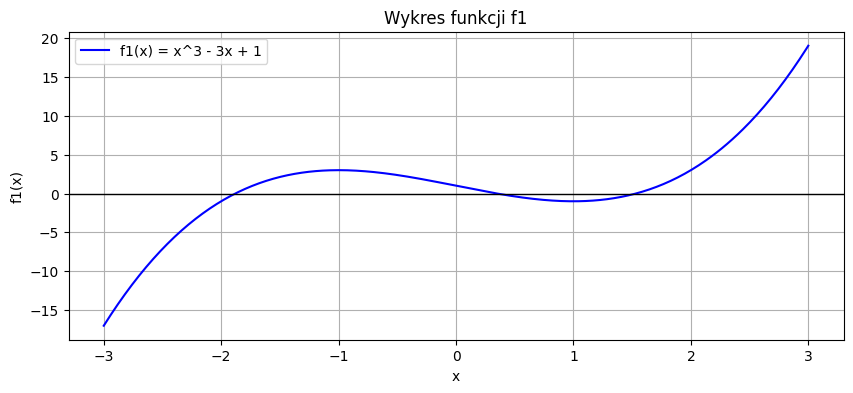

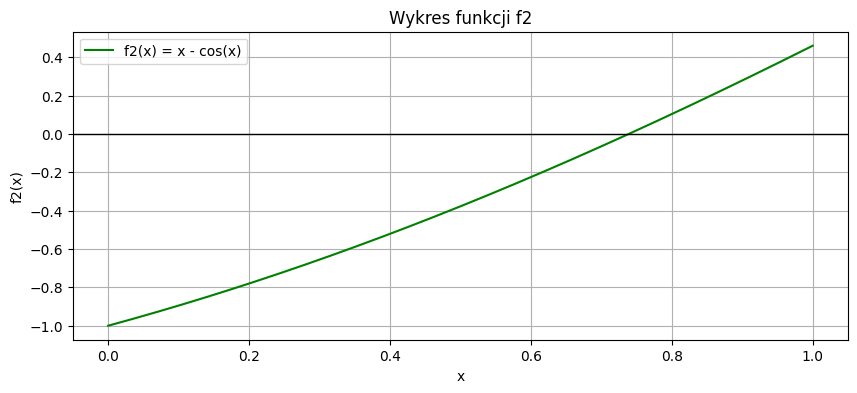

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Tworzymy wektory x dla wykresów
x1 = np.linspace(-3, 3, 400)
x2 = np.linspace(0, 1, 400)

# Obliczamy wartości funkcji
y1 = f1(x1)
y2 = f2(x2)

# Rysujemy wykres f1
plt.figure(figsize=(10,4))
plt.plot(x1, y1, label="f1(x) = x^3 - 3x + 1", color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.title("Wykres funkcji f1")
plt.xlabel("x")
plt.ylabel("f1(x)")
plt.grid(True)
plt.legend()
plt.show()

# Rysujemy wykres f2
plt.figure(figsize=(10,4))
plt.plot(x2, y2, label="f2(x) = x - cos(x)", color='green')
plt.axhline(0, color='black', linewidth=1)
plt.title("Wykres funkcji f2")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.grid(True)
plt.legend()
plt.show()

# Zadania: Zastosowania bisekcji

W tym zadaniu wykorzystasz swoją funkcję `bisection(f, a, b, n)` do rozwiązania praktycznych problemów.  

---

## Zadanie 1: Wzrost populacji bernikli kanadyjskich

Populacja bernikli kanadyjskich rośnie według wzoru logistycznego:

$$
P(t) = \frac{1000}{1 + 9 e^{-0.3 t}}
$$

Twoim zadaniem jest znaleźć **czas $t$, w którym populacja bernikli osiągnie 800**.

**Instrukcje:**

1. Zdefiniuj funkcję $f(t)$ jako różnicę pomiędzy populacją a 800:  
   $$f(t) = P(t) - 800$$
2. Wybierz odpowiedni przedział `[a,b]`, w którym populacja zmienia znak względem wartości 800.  
3. Użyj funkcji `bisection` z n krokami, np. `n=20`.  
4. Wydrukuj przybliżony czas `t`.

---
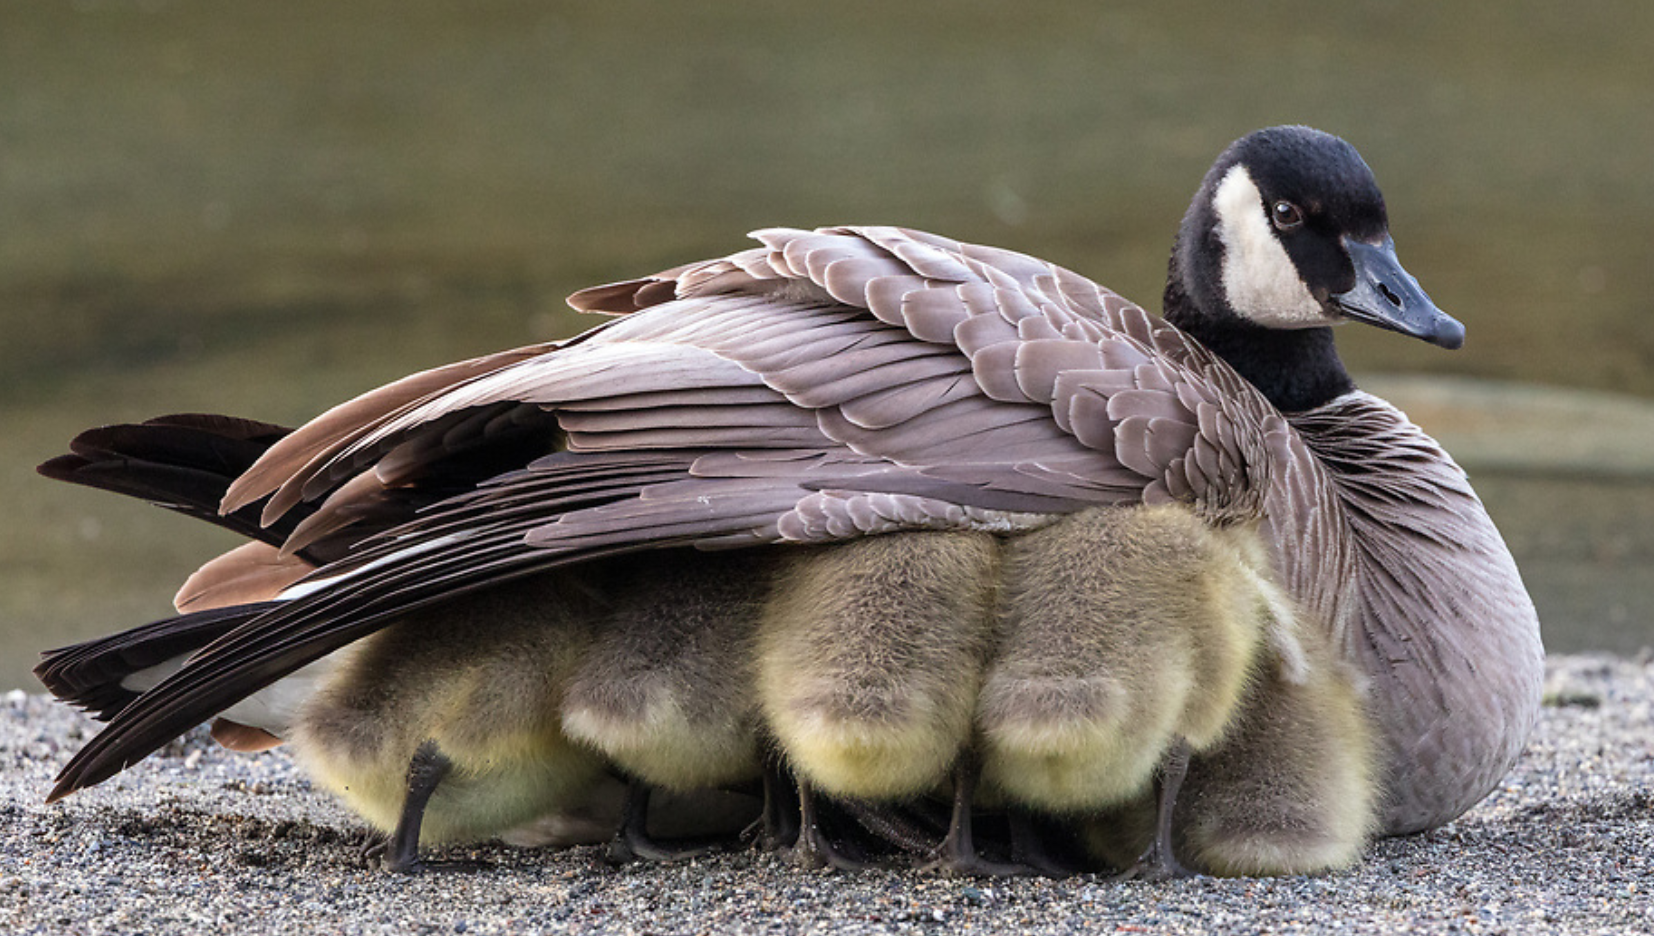

In [7]:
# Funkcja opisująca populację bernikli
def P(t):
    return 1000 / (1 + 9 * math.exp(-0.3 * t))

# Funkcja do bisekcji: różnica populacji od wartości docelowej 800
def f(t):
    return P(t) - 800

# Wybieramy przedział t, w którym populacja zmienia znak
a, b = 0, 20  # w tym przedziale funkcja zmienia znak

# Znajdujemy czas t przy pomocy bisekcji
t_root = bisection(f, a, b, n=20)

print(f"Czas, w którym populacja bernikli osiąga 800: t ≈ {t_root:.2f} jednostek czasu")

Czas, w którym populacja bernikli osiąga 800: t ≈ 11.95 jednostek czasu


# Zadanie 2: Maksymalizacja przychodu z nieliniowym popytem

Popyt $D(p)$ spada nieliniowo z ceną:

$$
D(p) = 100 \cdot e^{-0.05 p} - 2
$$

Przychód to $R(p) = p \cdot D(p)$.  
Znajdź cenę $p$, przy której przychód osiąga wartość $R = 50$ zł.  
Zdefiniuj funkcję, której pierwiastek odpowiada tej cenie i użyj bisekcji.:

In [8]:
# Popyt nieliniowy
def D(p):
    return 100 * math.exp(-0.05 * p) - 2

# Przychód
def R(p):
    return p * D(p)

# Funkcja do bisekcji: różnica przychodu od 50 zł
def f(p):
    return R(p) - 50

# Wybieramy przedział, w którym przychód osiąga wartość 50
a, b = 0, 50  # przedział musi obejmować pierwiastek

# Znajdujemy cenę przy pomocy bisekcji
p_root = bisection(f, a, b, n=20)

print(f"Cena, przy której przychód wynosi 50 zł: p ≈ {p_root:.2f} zł")

Cena, przy której przychód wynosi 50 zł: p ≈ 0.52 zł
